# Supplementary Tables

In [10]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gs
import h5py

import EIANN.utils as ut
import EIANN.plot as pt
from EIANN.generate_figures import *

pt.update_plot_defaults()
root_dir = ut.get_project_root()
model_dict_all = load_model_dict()

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
def generate_model_summary_table(model_dict_all, model_list, figure_name, dataset="MNIST"):
    num_rows = len(model_list)
    fig, ax = plt.subplots(figsize=(7, num_rows*0.26 + 0.4))
    ax.axis('off')

    columns = {'display_name': 0.17, 'Architecture': 0.12, 
                'Hidden Layers': 0.12, 'Algorithm': 0.12, 
                'W Learning Rule': 0.17, 'B Learning Rule': 0.17, 'Bias': 0.08}
    table_vals = []

    for model_key in model_list:
        model_dict = model_dict_all[model_key]
        network_name = model_dict['config'].split('.')[0]
        hdf5_path = root_dir + f"/EIANN/data/model_hdf5_plot_data/plot_data_{network_name}.h5"
        network_table_vals = [model_dict[col] for col in columns.keys() if col in model_dict]
        with h5py.File(hdf5_path, 'r') as f:
            # print(f"Generating table for {network_name}")
            data_dict = f[network_name]

            # Get the accuracy for each seed
            accuracy_all_seeds = []
            for seed in model_dict['seeds']:
                accuracy_all_seeds.append(data_dict[seed]['test_accuracy_history'][-1])
            avg_accuracy = np.mean(accuracy_all_seeds)
            std_accuracy = np.std(accuracy_all_seeds)
            sem_accuracy = std_accuracy / np.sqrt(len(accuracy_all_seeds))

            accuracy_all_seeds_extended = []
            for seed in model_dict['seeds']:
                accuracy_all_seeds_extended.append(data_dict[seed]['test_accuracy_history_extended'][-1])
            avg_accuracy_extended = np.mean(accuracy_all_seeds_extended)
            std_accuracy_extended = np.std(accuracy_all_seeds_extended)
            sem_accuracy_extended = std_accuracy_extended / np.sqrt(len(accuracy_all_seeds_extended))

            if dataset == "MNIST":
                new_column_labels = ['MNIST Accuracy \n(20k samples)', 
                                        'MNIST Accuracy \n(50k samples)']
                network_table_vals += [f"{avg_accuracy:.2f} \u00b1 {sem_accuracy:.2f}", 
                                        f"{avg_accuracy_extended:.2f} \u00b1 {sem_accuracy_extended:.2f}"]
            elif dataset == "FMNIST":
                new_column_labels = ['FMNIST Accuracy \n(20k samples)', 
                                        'FMNIST Accuracy \n(50k samples)']
                network_table_vals += [f"{avg_accuracy:.2f} \u00b1 {sem_accuracy:.2f}", 
                                        f"{avg_accuracy_extended:.2f} \u00b1 {sem_accuracy_extended:.2f}"]
            elif dataset == "spiral":
                new_column_labels = ['Spiral Accuracy \n(1 epoch)', 
                                        'Spiral Accuracy \n(10 epochs)']
                network_table_vals += [f"{avg_accuracy:.2f} \u00b1 {sem_accuracy:.2f}", 
                                        f"{avg_accuracy_extended:.2f} \u00b1 {sem_accuracy_extended:.2f}"]
                
        table_vals.append(network_table_vals)

    column_labels = list(columns.keys()) + new_column_labels
    column_labels[0] = ""
    col_widths = list(columns.values()) + [0.14, 0.14]

    table = ax.table(cellText=table_vals, colLabels=column_labels, cellLoc="center", loc="center", colWidths=col_widths)
    table.auto_set_font_size(False)

    for key, cell in table.get_celld().items():
        cell.set_linewidth(0)
        cell.set_height(cell.get_height() * 1.5)
        cell.set_text_props(fontname='Arial', fontsize=6)
        if key[0] == 0: # Header row
            cell.set_facecolor([0.9 for i in range(3)])
            cell.set_text_props(weight='bold')
            cell.set_height(cell.get_height() * 1.2)
        elif key[0] % 2 == 0: # Even rows
            cell.set_facecolor([0.96 for i in range(3)]) # make even rows light grey

        if key[1] == 0: # First column
            cell.set_text_props(horizontalalignment='left', weight='semibold')

    fig.savefig(f"{root_dir}/EIANN/figures/{figure_name}.png", dpi=300)
    fig.savefig(f"{root_dir}/EIANN/figures/{figure_name}.svg", dpi=300)

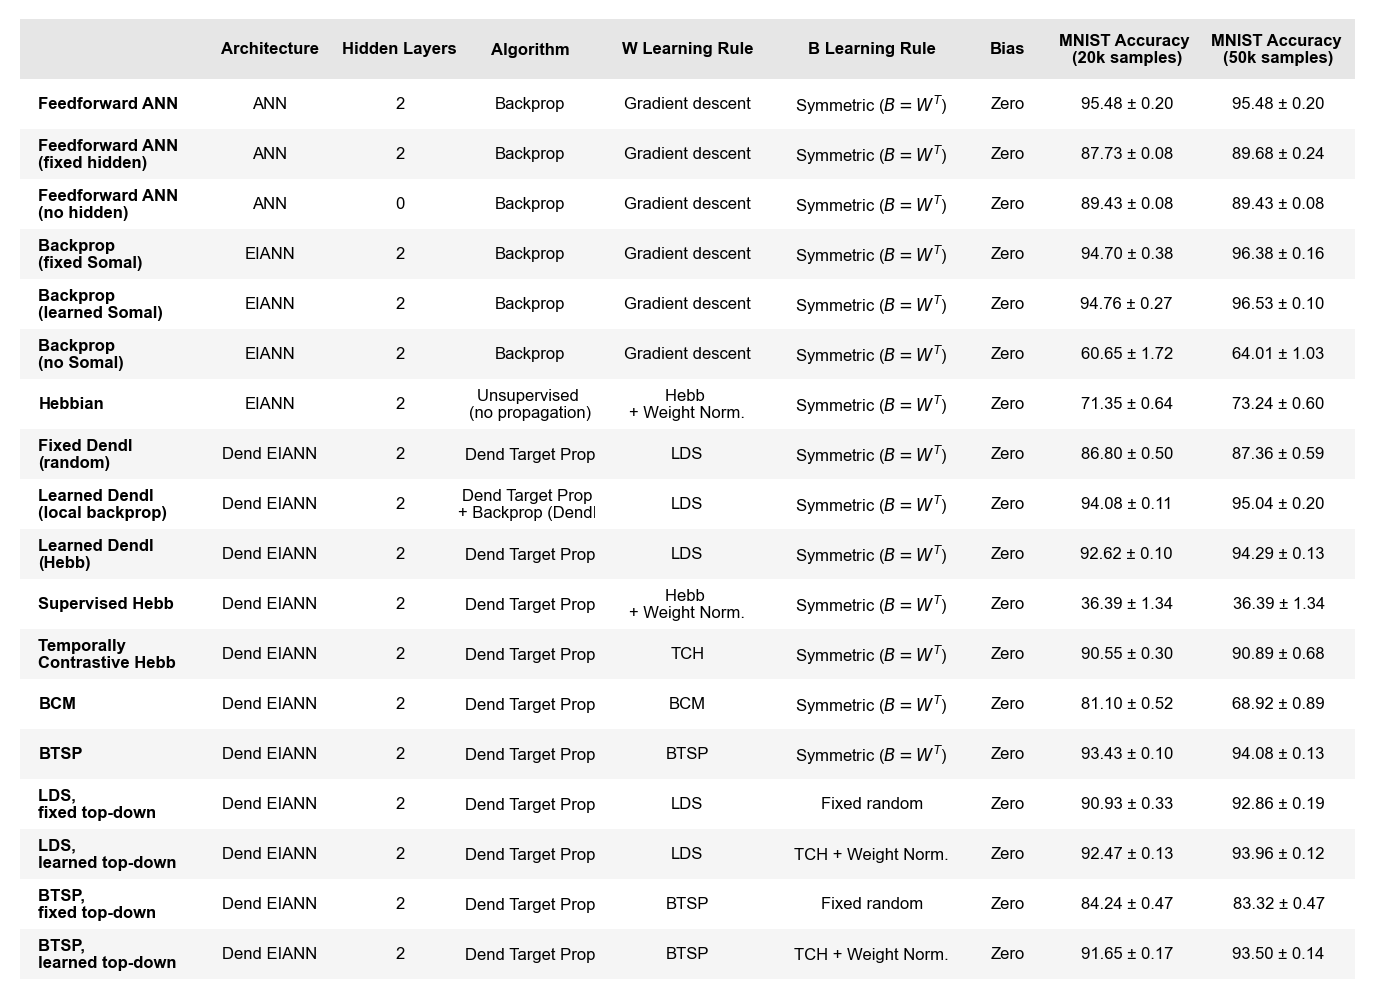

In [ ]:
figure_name = "FigT1_mnist_table"

model_list = ["vanBP", "vanBP_fixed_hidden", "vanBP_0hidden",
              "bpDale_fixed", "bpDale_learned", "bpDale_noI", 
              "HebbWN_topsup", "bpLike_WT_fixedDend", "bpLike_WT_localBP", "bpLike_WT_hebbdend", 
              "Supervised_HebbWN_WT_hebbdend", "SupHebbTempCont_WT_hebbdend" , "Supervised_BCM_WT_hebbdend", "BTSP_WT_hebbdend",
              "bpLike_fixedTD_hebbdend", "bpLike_TCWN_hebbdend", "BTSP_fixedTD_hebbdend", "BTSP_TCWN_hebbdend"]

generate_hdf5_all_seeds(model_list, model_dict_all, recompute=None, variables_to_save=['test_accuracy_history', 'test_accuracy_history_extended'])

generate_model_summary_table(model_dict_all, model_list, figure_name, dataset="MNIST")

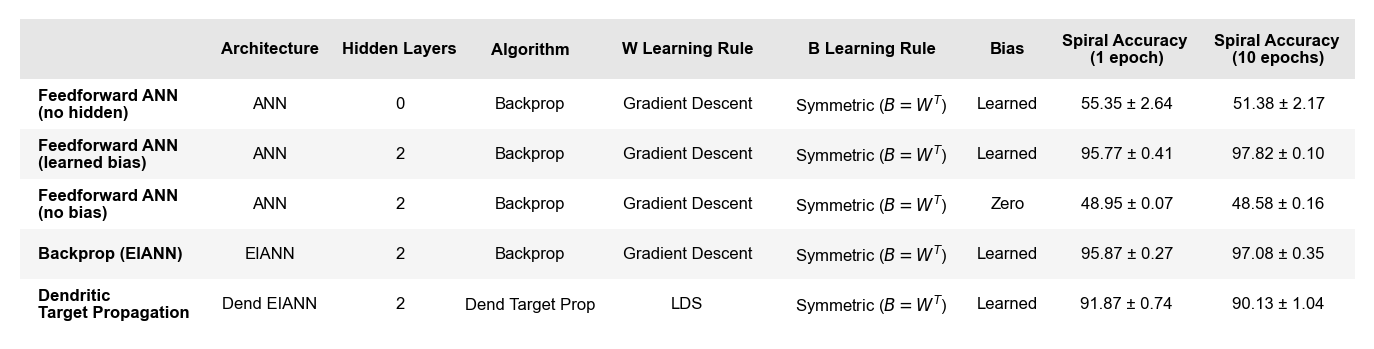

In [13]:
figure_name = "FigT2_spiral_table"

model_list = ["vanBP_0_hidden_learned_bias_spiral", "vanBP_2_hidden_learned_bias_spiral", 
              "vanBP_2_hidden_zero_bias_spiral", "bpDale_learned_bias_spiral", "DTP_learned_bias_spiral"]

generate_hdf5_all_seeds(model_list, model_dict_all, recompute=None, dataset='spiral', variables_to_save=['test_accuracy_history', 'test_accuracy_history_extended'])

generate_model_summary_table(model_dict_all, model_list, figure_name, dataset="spiral")

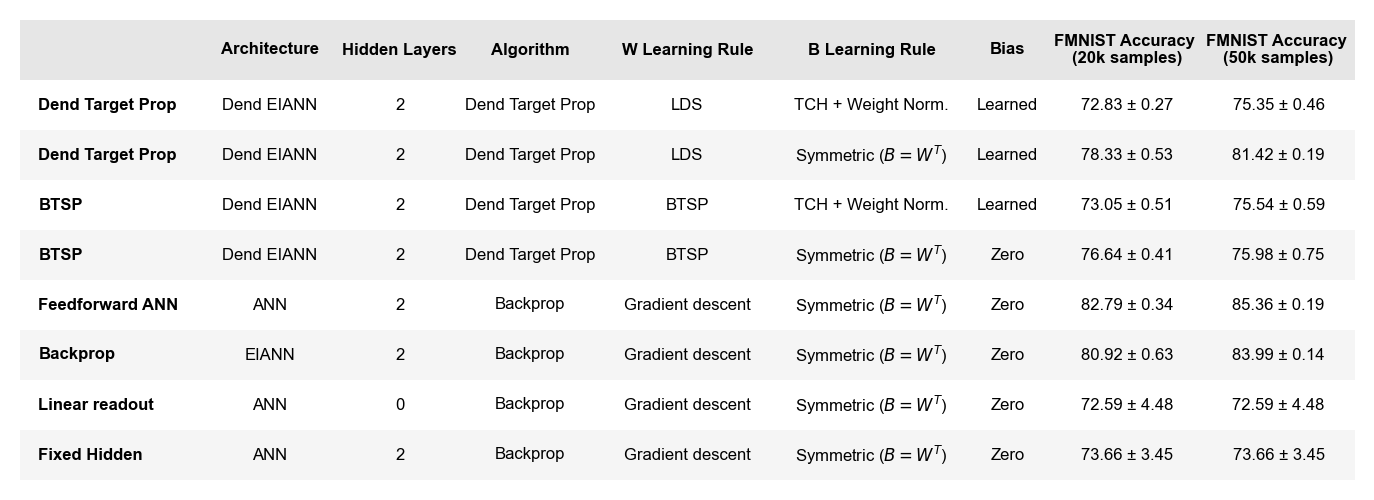

In [14]:
figure_name = "FigT7_fmnist_table"

model_list = ["fmnist_DTP_TCWN_hebbdend", "fmnist_DTP_WT_hebbdend", "fmnist_BTSP_TCWN_hebbdend", "fmnist_BTSP_WT_nobias_hebbdend", 
                "fmnist_vanBP_nobias", "fmnist_bpDale_nobias", "fmnist_0hidden_vanBP_nobias", "fmnist_fixed_vanBP_nobias"]

generate_hdf5_all_seeds(model_list, model_dict_all, recompute=None, dataset='fmnist', variables_to_save=['test_accuracy_history', 'test_accuracy_history_extended'])

generate_model_summary_table(model_dict_all, model_list, figure_name, dataset="FMNIST")